# recount2 — C2CP Pathway Coverage vs Sample Size (fixed K multiplier)

**Environment:** `clamp-analyses`

Plots the C2CP pathway coverage and K results produced by `03_recount2_coverage_multiplier.ipynb`.

Coverage = proportion of input C2CP pathways significantly associated with an LV (FDR < 0.05),
following the `GetPathwayCoverage` approach from the multi-plier paper (Taroni 2018).

Input: `output/recount2_multiplier/c2cp_subsample_{N}_seed_{seed}/CLAMPfull_C2CP.rds`

Seeds and CLAMP_K per sample size are read from `data/archs4/subsampled_number_of_lvs.tsv`.

## Libraries

In [1]:
library(dplyr)
library(ggplot2)
library(here)

source(here("config.R"))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Configuration

In [2]:
FDR_CUTOFF <- 0.05
output_dir <- file.path(config$GENERAL$OUTPUT_DIR, "recount2_multiplier")

lvs_tsv <- read.table(
    here("data", "archs4", "subsampled_number_of_lvs.tsv"),
    header     = TRUE,
    sep        = "\t",
    colClasses = c(number_of_latent_variables = "integer",
                   seed                       = "integer",
                   sample_size                = "integer")
)

## Coverage function

In [3]:
# Adapted from GetPathwayCoverage (Taroni 2018 / multi-plier)
GetPathwayCoverage <- function(clamp.result, fdr.cutoff = 0.05) {
    summary.df     <- clamp.result$summary
    input.pathways <- colnames(clamp.result$C)
    num.lvs        <- ncol(clamp.result$U)

    sig.pathways <- unique(summary.df$pathway[which(summary.df$FDR < fdr.cutoff)])
    sig.lvs      <- unique(summary.df$LV[which(summary.df$FDR < fdr.cutoff)])

    list(
        pathway           = length(sig.pathways) / length(input.pathways),
        lv                = length(sig.lvs) / num.lvs,
        sig.pathway.by.lv = length(sig.pathways) / num.lvs
    )
}

## Collect results per run

In [4]:
rows <- list()

for (i in seq_len(nrow(lvs_tsv))) {
    n_target     <- lvs_tsv$sample_size[i]
    current_seed <- lvs_tsv$seed[i]
    clamp_k_tsv  <- lvs_tsv$number_of_latent_variables[i]

    run_dir  <- file.path(output_dir,
                          paste0("c2cp_subsample_", n_target, "_seed_", current_seed))
    rds_path <- file.path(run_dir, "CLAMPfull_C2CP.rds")
    k_path   <- file.path(run_dir, "CLAMP_K.rds")

    if (!file.exists(rds_path)) {
        message("Not found — skipping: c2cp_subsample_",
                n_target, "_seed_", current_seed)
        next
    }

    model   <- readRDS(rds_path)
    clamp_k <- if (file.exists(k_path)) readRDS(k_path) else clamp_k_tsv
    cov     <- GetPathwayCoverage(model, fdr.cutoff = FDR_CUTOFF)

    rows[[length(rows) + 1]] <- data.frame(
        sample_size      = n_target,
        n_samples        = ncol(model$B),
        seed             = current_seed,
        pathway_coverage = cov$pathway,
        lv_coverage      = cov$lv,
        clamp_k          = clamp_k
    )
    message(sprintf("n=%6d  seed=%d  pathway_cov=%.2f%%  K=%d",
                    n_target, current_seed,
                    cov$pathway * 100, clamp_k))
}

results_df <- dplyr::bind_rows(rows) %>%
    dplyr::mutate(sample_size = factor(sample_size,
                                       levels = sort(unique(sample_size))))
print(results_df)

n=  1000  seed=2876  pathway_cov=4.98%  K=48

n=  1000  seed=7883  pathway_cov=4.16%  K=38

n=  1000  seed=4089  pathway_cov=4.68%  K=49

n=  1000  seed=8828  pathway_cov=4.12%  K=29

n=  1000  seed=9401  pathway_cov=5.62%  K=49

Not found — skipping: c2cp_subsample_16000_seed_2876

Not found — skipping: c2cp_subsample_16000_seed_7883

Not found — skipping: c2cp_subsample_16000_seed_4089

Not found — skipping: c2cp_subsample_16000_seed_8828

Not found — skipping: c2cp_subsample_16000_seed_9401

n=  2000  seed=2876  pathway_cov=6.48%  K=68

n=  2000  seed=7883  pathway_cov=3.03%  K=18

n=  2000  seed=4089  pathway_cov=7.46%  K=91

n=  2000  seed=8828  pathway_cov=6.48%  K=108

n=  2000  seed=9401  pathway_cov=5.58%  K=42

Not found — skipping: c2cp_subsample_32000_seed_2876

Not found — skipping: c2cp_subsample_32000_seed_7883

Not found — skipping: c2cp_subsample_32000_seed_4089

Not found — skipping: c2cp_subsample_32000_seed_8828

Not found — skipping: c2cp_subsample_32000_seed_9401


   sample_size n_samples seed pathway_coverage lv_coverage clamp_k
1         1000      1000 2876       0.04983140   0.8750000      48
2         1000      1000 7883       0.04158861   0.8421053      38
3         1000      1000 4089       0.04683402   0.8571429      49
4         1000      1000 8828       0.04121394   0.9655172      29
5         1000      1000 9401       0.05620082   0.9591837      49
6         2000      2000 2876       0.06481828   0.8970588      68
7         2000      2000 7883       0.03034845   0.9444444      18
8         2000      2000 4089       0.07455976   0.8461538      91
9         2000      2000 8828       0.06481828   0.6296296     108
10        2000      2000 9401       0.05582615   0.9285714      42
11         500       500 2876       0.03934058   0.9333333      30
12         500       500 7883       0.03446984   0.8000000      30
13         500       500 4089       0.04421132   1.0000000      27
14         500       500 8828       0.03934058   0.7169811    

## Pathway coverage

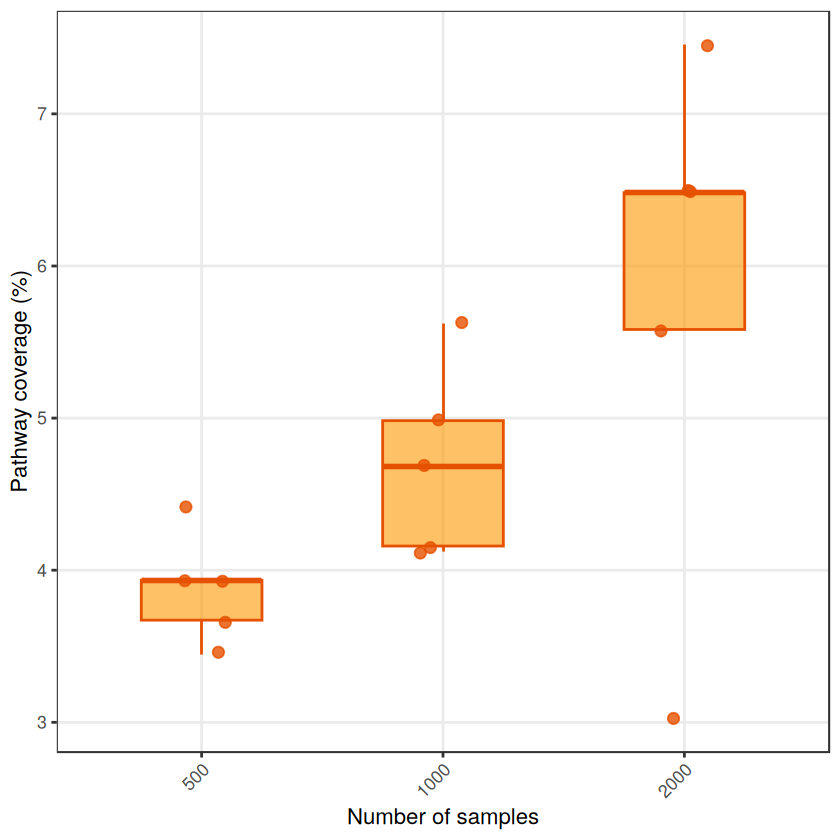

In [5]:
p_cov <- ggplot(results_df,
                aes(x = sample_size, y = pathway_coverage * 100)) +
    geom_boxplot(fill = "#FF9800", color = "#E65100",
                 alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(color = "#E65100", width = 0.1, size = 2.5, alpha = 0.8) +
    labs(
        x       = "Number of samples",
        y       = "Pathway coverage (%)",
    ) +
    theme_bw(base_size = 13) +
    theme(
        axis.text.x      = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank()
    )

print(p_cov)

## K (number of components)

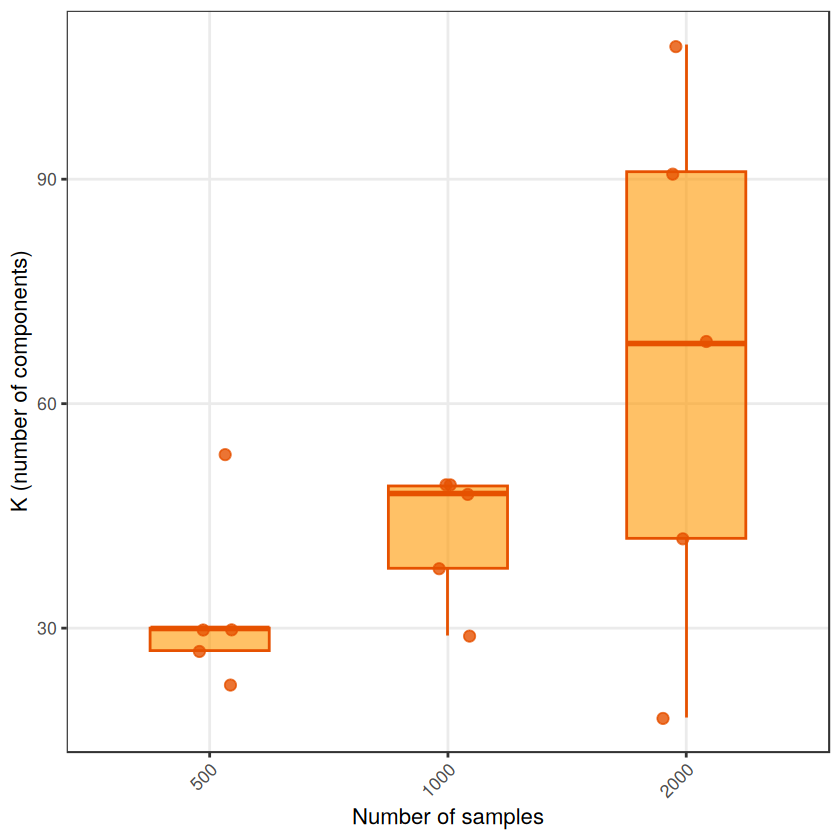

In [6]:
p_k <- ggplot(results_df,
              aes(x = sample_size, y = clamp_k)) +
    geom_boxplot(fill = "#FF9800", color = "#E65100",
                 alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(color = "#E65100", width = 0.1, size = 2.5, alpha = 0.8) +
    labs(
        x = "Number of samples",
        y = "K (number of components)"
    ) +
    theme_bw(base_size = 13) +
    theme(
        axis.text.x      = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank()
    )

print(p_k)

## Summary table

In [7]:
results_df %>%
    dplyr::group_by(sample_size) %>%
    dplyr::summarise(
        median_cov = round(median(pathway_coverage) * 100, 2),
        min_cov    = round(min(pathway_coverage) * 100, 2),
        max_cov    = round(max(pathway_coverage) * 100, 2),
        median_k   = median(clamp_k, na.rm = TRUE),
        n          = dplyr::n(),
        .groups    = "drop"
    ) %>%
    dplyr::arrange(sample_size)

sample_size,median_cov,min_cov,max_cov,median_k,n
<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>
500,3.93,3.45,4.42,30,5
1000,4.68,4.12,5.62,48,5
2000,6.48,3.03,7.46,68,5
